In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


In [90]:
df = pd.read_csv('AAPL_historical_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
print(df.shape)
df.head()

(11094, 4)


,Open,High,Low,Close
Date,,,,
1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834
1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678
1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802
1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951
1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530


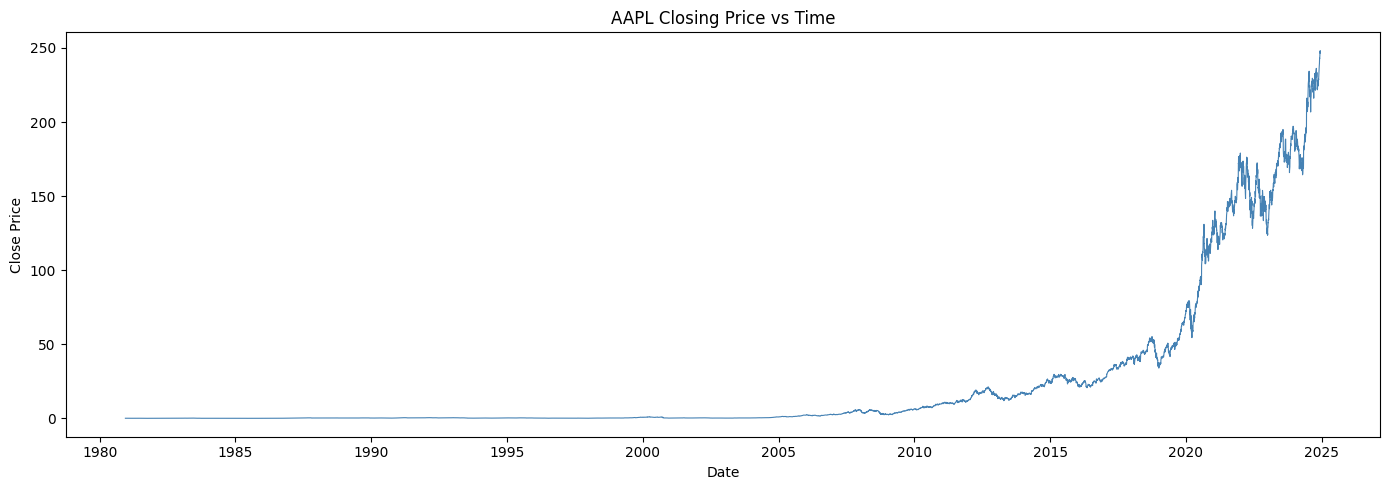

In [91]:
#1(a) Line Plot: Closing Price vs Time
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=0.8)
plt.title('AAPL Closing Price vs Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.tight_layout()
plt.show()

In [92]:
#1(b) One-Day Lag and Pearson Correlation
df['lag1'] = df['Close'].shift(1)
df_clean = df[['Close', 'lag1']].dropna()

corr_coef, p_value = pearsonr(df_clean['Close'], df_clean['lag1'])
print(f'Pearson Correlation (lag-1) = {corr_coef:.6f}')
print(f'p-value = {p_value:.2e}')

Pearson Correlation (lag-1) = 0.999826
p-value = 0.00e+00


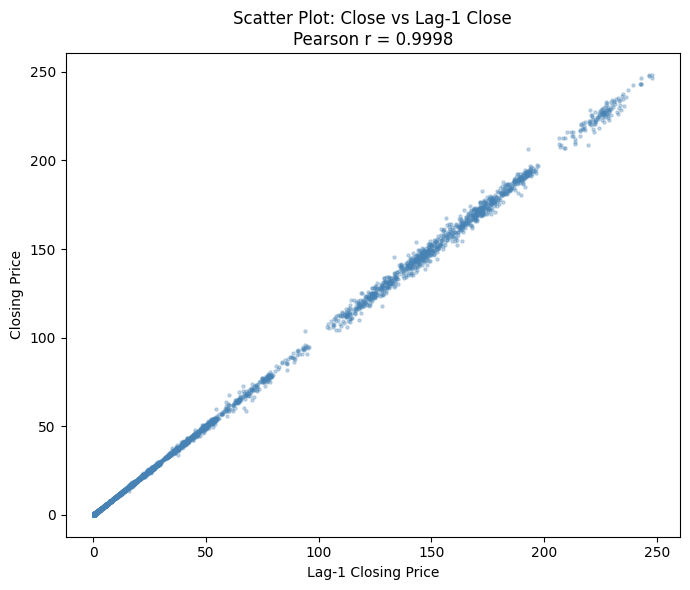

In [93]:
#(c) Scatter Plot: Closing Price vs Lag-1
plt.figure(figsize=(7, 6))
plt.scatter(df_clean['lag1'], df_clean['Close'], alpha=0.3, s=5, color='steelblue')
plt.title(f'Scatter Plot: Close vs Lag-1 Close\nPearson r = {corr_coef:.4f}')
plt.xlabel('Lag-1 Closing Price')
plt.ylabel('Closing Price')
plt.tight_layout()
plt.show()

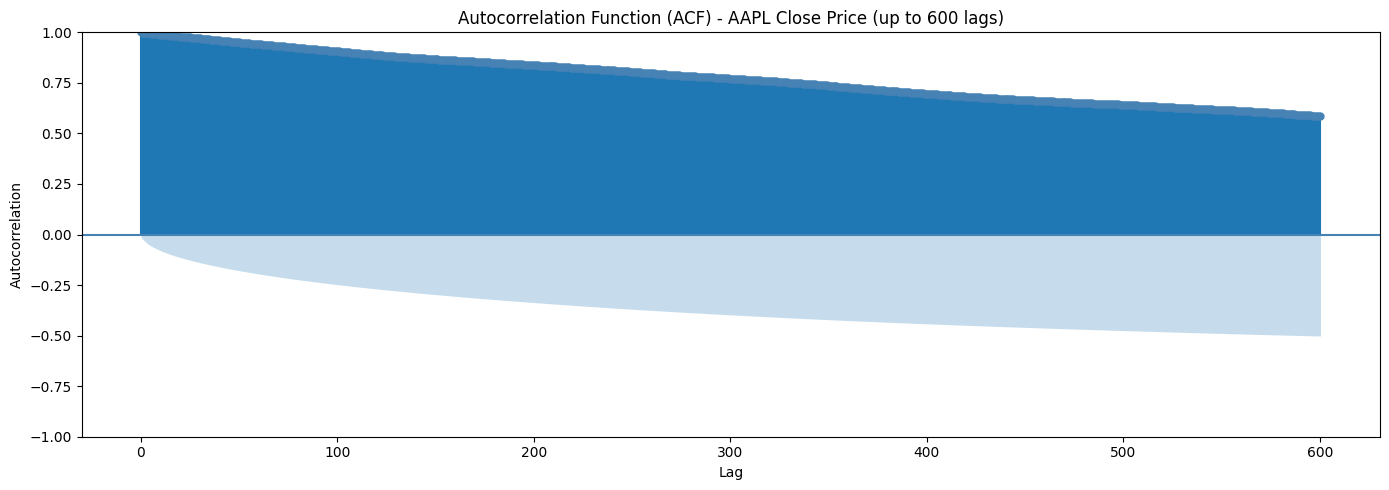

In [94]:
#1(d) Autocorrelation Function (ACF) up to 600 Lags
fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(df['Close'].dropna(), lags=600, ax=ax, color='steelblue', alpha=0.05)
ax.set_title('Autocorrelation Function (ACF) - AAPL Close Price (up to 600 lags)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

Training samples : 10000
Test samples     : 1094


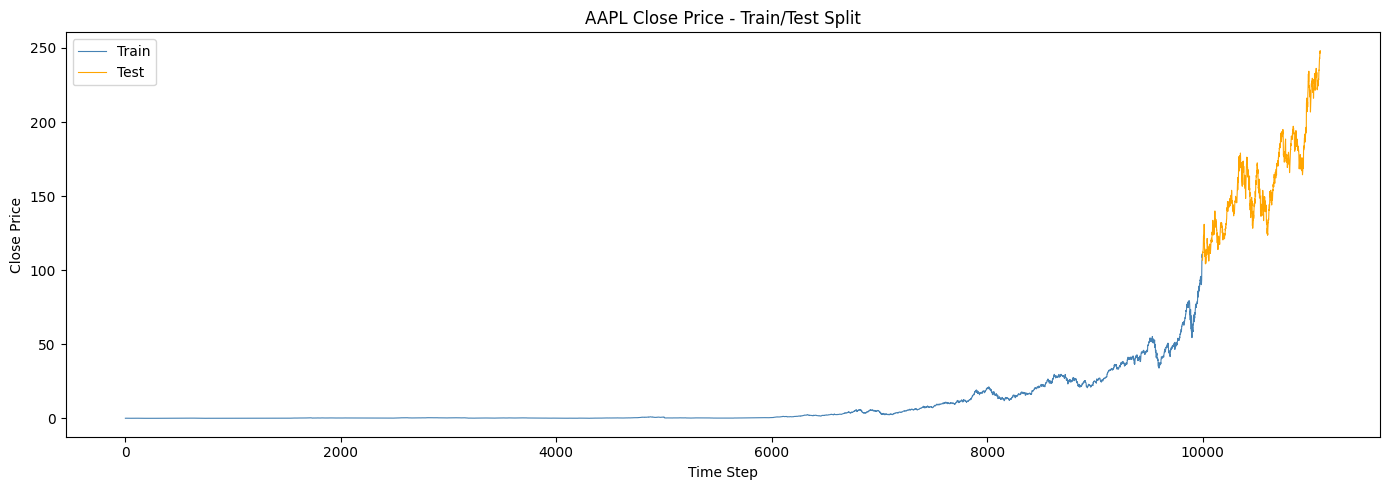


AR(5) Coefficients:
  w0 = -0.005007
  w1 = 0.853795
  w2 = 0.189636
  w3 = -0.031688
  w4 = 0.004280
  w5 = -0.013935


In [95]:
# Drop NaNs
close_series = df['Close'].dropna()

# Convert to NumPy arrays
train = close_series.iloc[:10000].values
test  = close_series.iloc[10000:].values

print(f'Training samples : {len(train)}')
print(f'Test samples     : {len(test)}')

# Create custom indices
train_index = range(len(train))
test_index = range(len(train), len(train) + len(test))

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_index, train, label='Train', color='steelblue', linewidth=0.8)
plt.plot(test_index, test, label='Test', color='orange', linewidth=0.8)
plt.title('AAPL Close Price - Train/Test Split')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

# Fit AR(5) model
model_ar5 = AutoReg(train, lags=5).fit()

# Print coefficients
coef = model_ar5.params
print('\nAR(5) Coefficients:')
for i, c in enumerate(coef):
    print(f'  w{i} = {c:.6f}')

In [98]:
# 2(b) Ahead Predictions Using AR(5) Coefficient
def ar_predict_manual(train_series, test_series, coef, p=5):
    """
    1-step ahead prediction using AR coefficients.
    Formula: yhat(t) = w0 + w1*y(t-1) + ... + wp*y(t-p)
    
    Parameters:
    train_series : array-like, training data
    test_series  : array-like, test data
    coef         : array-like [w0, w1, ..., wp] (length p+1)
    p            : int, order of AR model
    """

    model = AutoReg(train_series, lags = p).fit()
    preds = model.predict(start=len(train_series), end=len(train_series)+len(test_series) - 1)
    return np.array(preds)

# --- Metrics ---
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# --- Example usage ---
# coef should be [w0, w1, w2, w3, w4, w5] from your AR(5) model
preds_ar5 = ar_predict_manual(train, test, coef, p=5)

r5 = rmse(test, preds_ar5)
m5 = mape(test, preds_ar5)

print(f'AR(5) RMSE : {r5:.4f}')
print(f'AR(5) MAPE : {m5:.4f}%')

AR(5) RMSE : 281.4408
AR(5) MAPE : 115.5293%


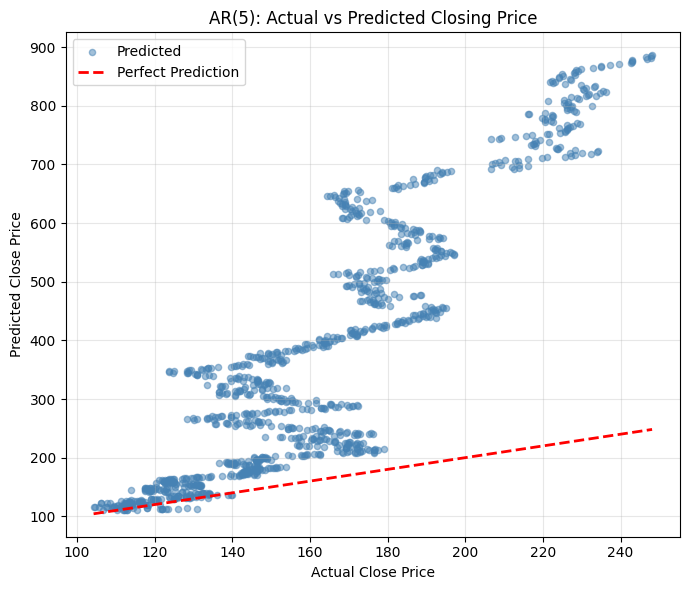

In [99]:
plt.figure(figsize=(7, 6))
plt.scatter(actual, preds_ar5, alpha=0.5, s=20, color='steelblue', label='Predicted')
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('AR(5): Actual vs Predicted Closing Price')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

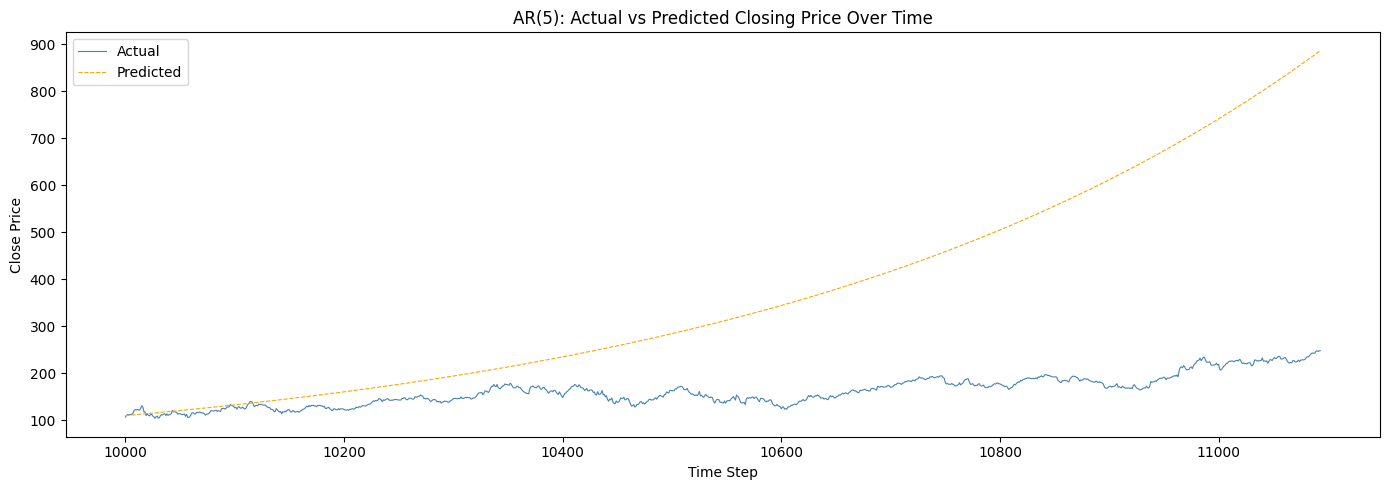

RMSE : 281.4408
MAPE : 115.5293%


In [100]:
# 2(b)(ii) Line plot: actual vs predicted over time
plt.figure(figsize=(14, 5))

plt.plot(test_index, actual,    label='Actual',    color='steelblue', linewidth=0.8)
plt.plot(test_index, preds_ar5, label='Predicted', color='orange', linewidth=0.8, linestyle='--')

plt.title('AR(5): Actual vs Predicted Closing Price Over Time')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

print(f'RMSE : {r5:.4f}')
print(f'MAPE : {m5:.4f}%')

In [102]:
# 3. AR Models with Different Lags

lag_values = [1, 5, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]

rmse_list = []
mape_list = []
all_preds = {}

for lag in lag_values:
    model = AutoReg(train, lags=lag).fit()

    preds = model.predict(start = len(train), end = len(train) + len(test) - 1)
    all_preds[lag] = preds

    r = rmse(actual, preds)
    m = mape(actual, preds)

    rmse_list.append(r)
    mape_list.append(m)

    print(f'Lag={lag:4d}  RMSE={r:.4f}  MAPE={m:.4f}%')

Lag=   1  RMSE=268.3857  MAPE=110.5718%
Lag=   5  RMSE=281.4408  MAPE=115.5293%
Lag=  10  RMSE=297.0584  MAPE=122.2502%
Lag=  50  RMSE=311.4168  MAPE=129.0044%
Lag= 100  RMSE=170.6706  MAPE=69.3673%
Lag= 150  RMSE=176.3458  MAPE=71.9769%
Lag= 200  RMSE=217.0915  MAPE=88.8958%
Lag= 250  RMSE=208.7411  MAPE=85.4392%
Lag= 300  RMSE=187.6075  MAPE=76.5594%
Lag= 350  RMSE=199.3821  MAPE=80.2831%
Lag= 400  RMSE=91.8442  MAPE=33.1565%
Lag= 450  RMSE=70.5829  MAPE=24.8801%
Lag= 500  RMSE=76.0736  MAPE=26.3764%
Lag= 550  RMSE=80.0841  MAPE=27.4545%
Lag= 600  RMSE=68.6283  MAPE=26.1205%


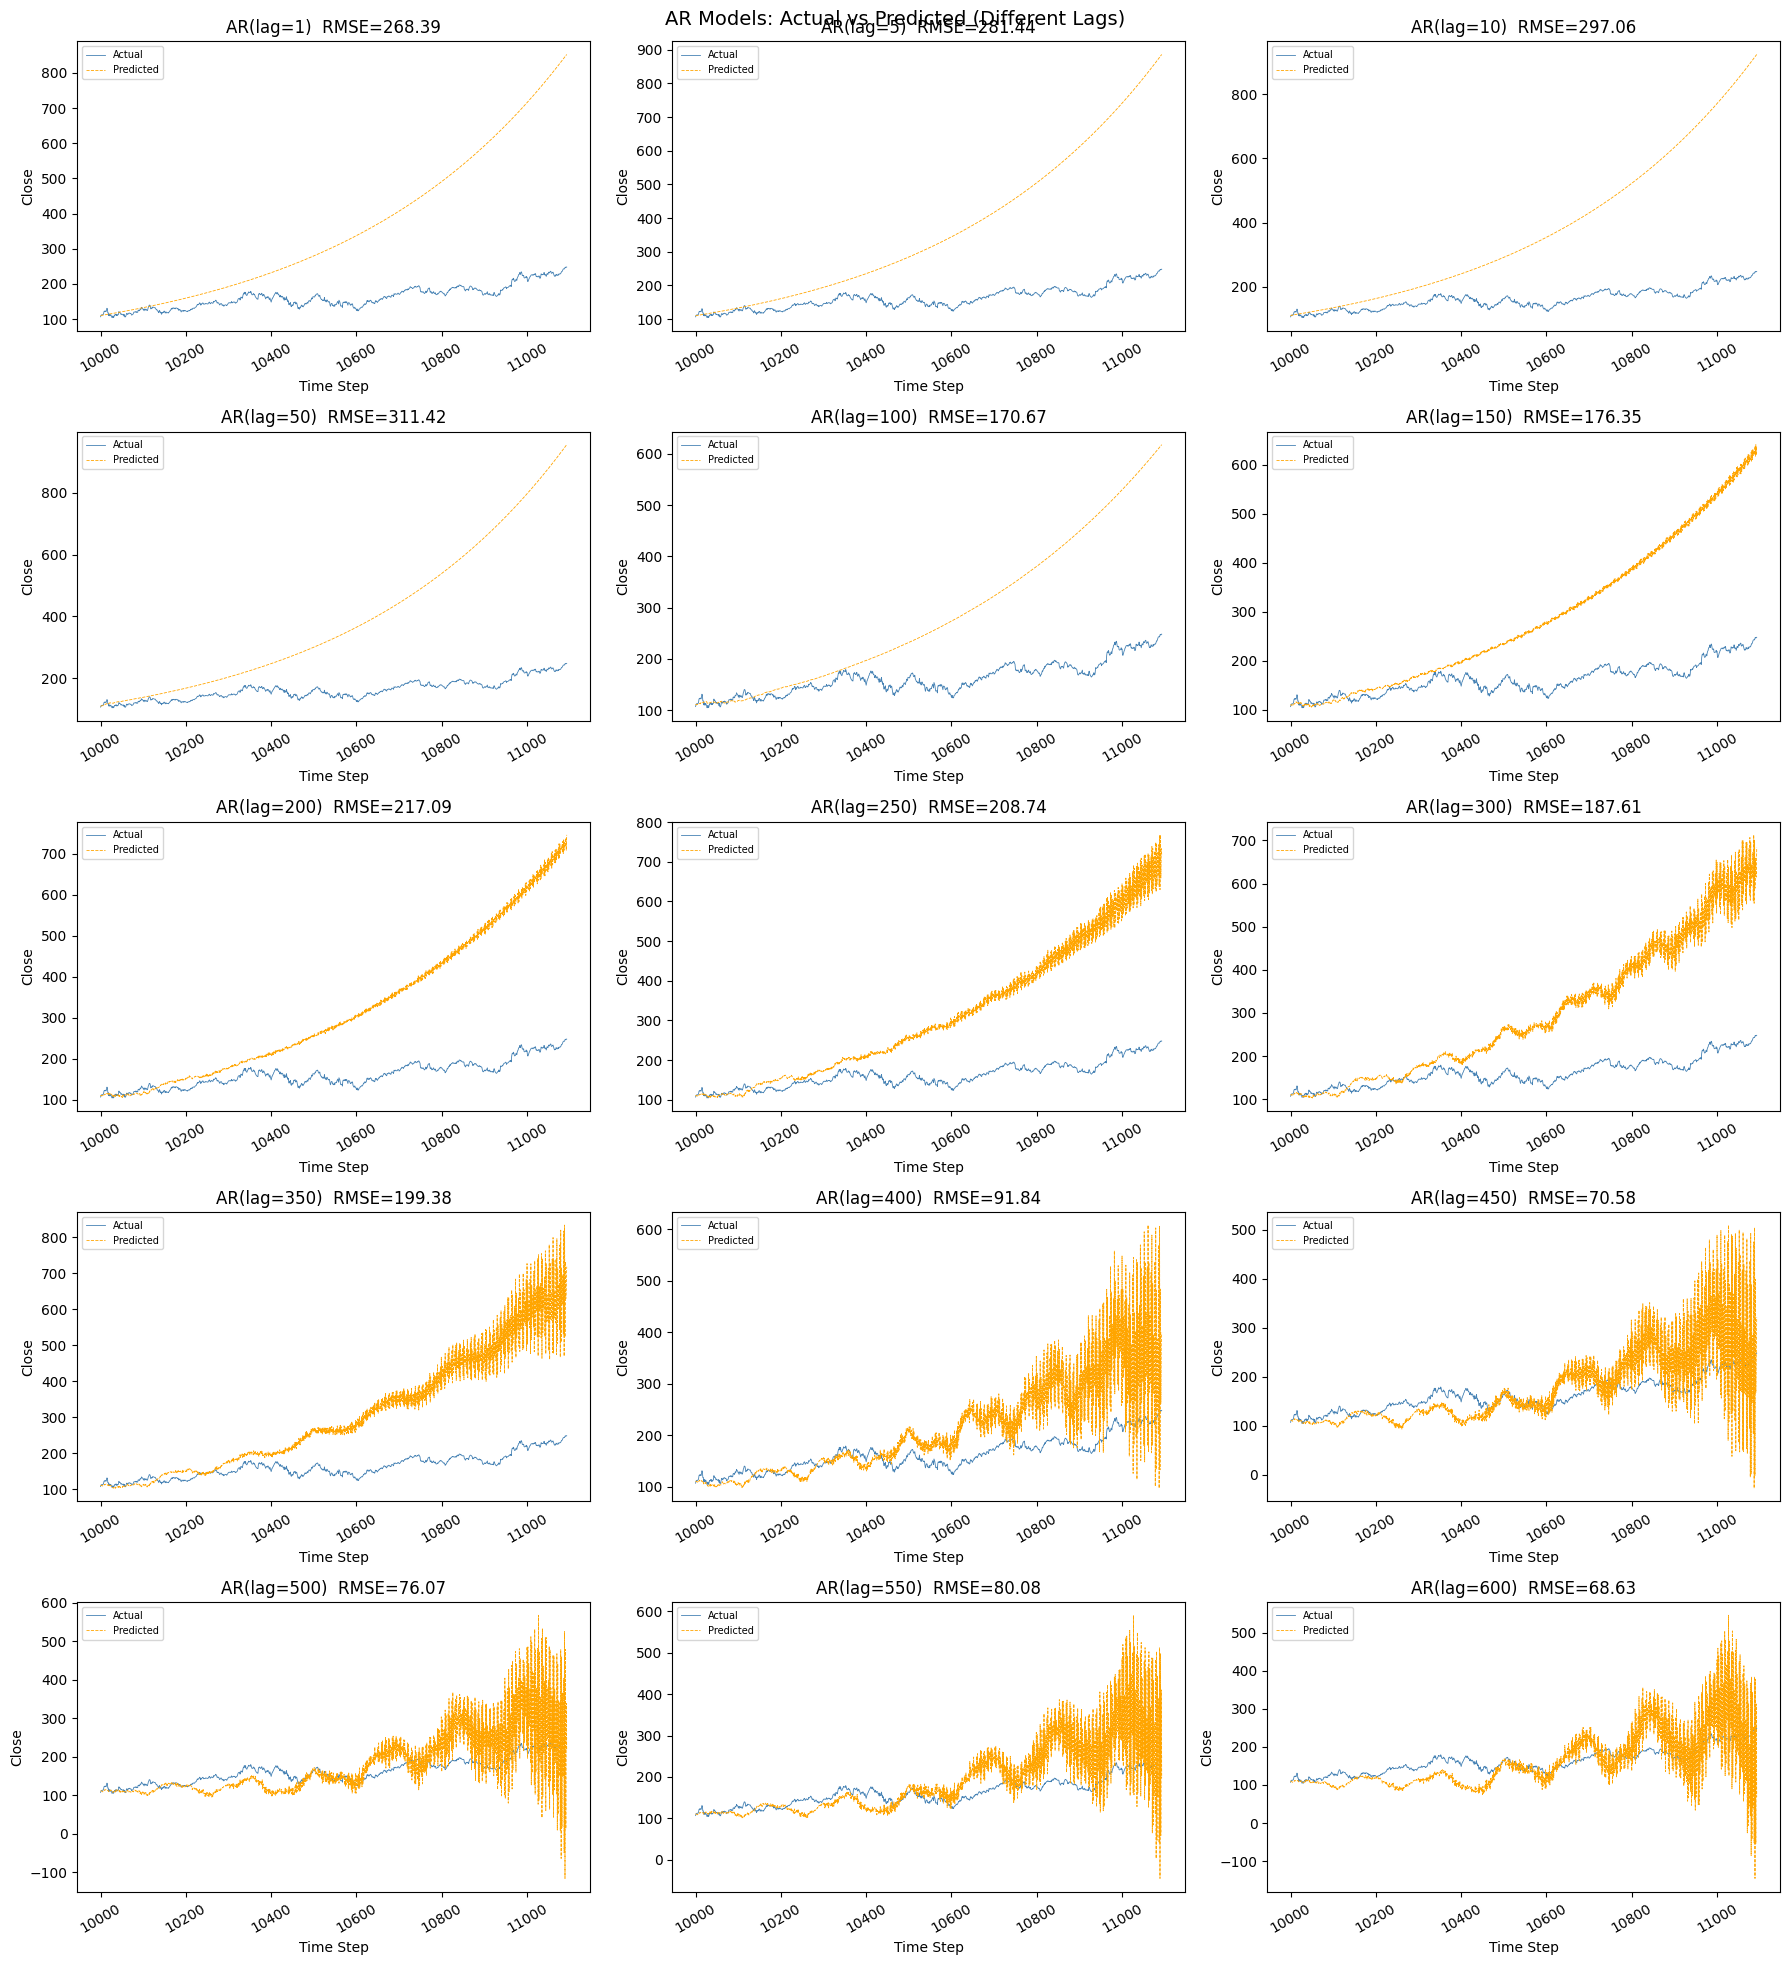

In [103]:
# 3a - Plot
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, lag in enumerate(lag_values):
    axes[idx].plot(test_index, actual, label='Actual', color='steelblue', linewidth=0.6)
    axes[idx].plot(test_index, all_preds[lag], label='Predicted', color='orange', linewidth=0.6, linestyle='--')

    axes[idx].set_title(f'AR(lag={lag})  RMSE={rmse_list[idx]:.2f}')
    axes[idx].set_xlabel('Time Step')
    axes[idx].set_ylabel('Close')
    axes[idx].legend(fontsize=7)
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('AR Models: Actual vs Predicted (Different Lags)', fontsize=14)
plt.tight_layout()
plt.show()

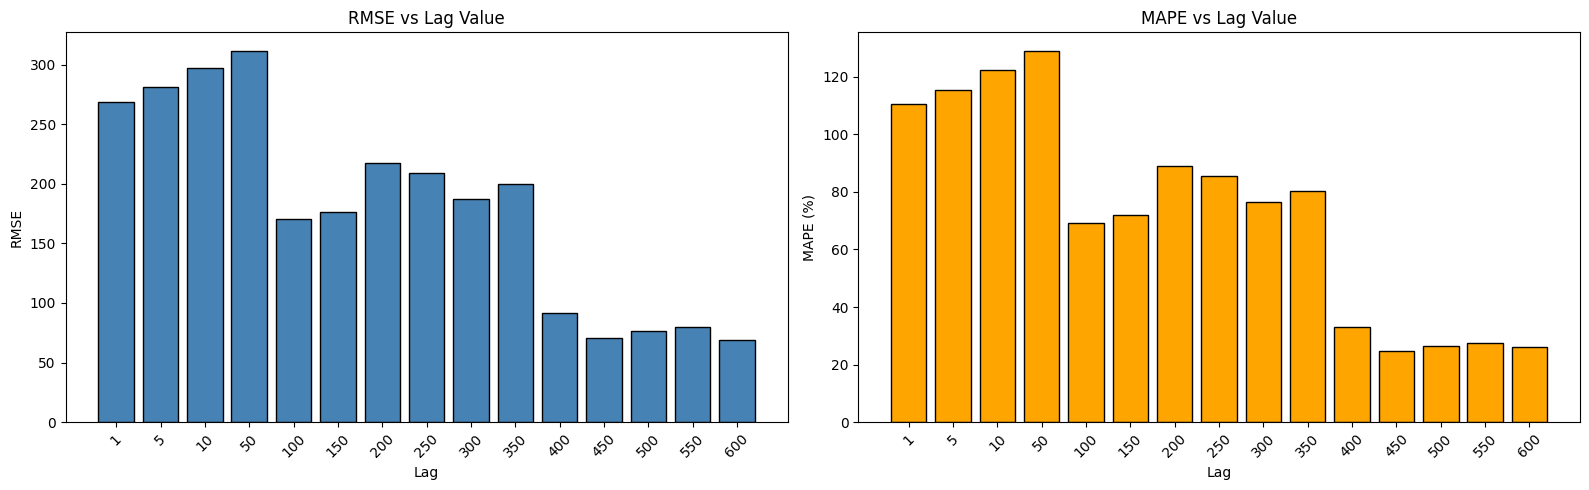

Best lag (min RMSE): 600


In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar([str(l) for l in lag_values], rmse_list, color='steelblue', edgecolor='black')
ax1.set_title('RMSE vs Lag Value')
ax1.set_xlabel('Lag')
ax1.set_ylabel('RMSE')
ax1.tick_params(axis='x', rotation=45)

ax2.bar([str(l) for l in lag_values], mape_list, color='orange', edgecolor='black')
ax2.set_title('MAPE vs Lag Value')
ax2.set_xlabel('Lag')
ax2.set_ylabel('MAPE (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

best_lag = lag_values[np.argmin(rmse_list)]
print(f'Best lag (min RMSE): {best_lag}')

In [105]:
# Optimal Lag selection 
from statsmodels.tsa.stattools import acf

T = len(train)
threshold = np.sqrt(2 / T)
print(f'T = {T}, Threshold = sqrt(2/T) = {threshold:.6f}')

# Compute ACF values up to 600 lags
acf_vals = acf(train, nlags=600, fft=True)

# Find optimal lag: largest lag where |ACF| > threshold
significant_lags = [i for i in range(1, len(acf_vals)) if abs(acf_vals[i]) > threshold]
optimal_lag = max(significant_lags) if significant_lags else 1
print(f'Optimal lag (heuristic) = {optimal_lag}')

# Fit AR model with optimal lag
model_opt = AutoReg(train, lags=optimal_lag).fit()
c_opt = model_opt.params

history = list(train)  # FIXED
preds_opt = []

for i in range(len(test)):
    lags_rev = history[-optimal_lag:][::-1]
    yhat = c_opt[0] + sum(c_opt[j+1] * lags_rev[j] for j in range(optimal_lag))
    preds_opt.append(yhat)

    history.append(test[i])  # FIXED

preds_opt = np.array(preds_opt)

# Metrics
r_opt = rmse(actual, preds_opt)
m_opt = mape(actual, preds_opt)

print(f'Optimal AR({optimal_lag}) RMSE : {r_opt:.4f}')
print(f'Optimal AR({optimal_lag}) MAPE : {m_opt:.4f}%')

# Comparison
print('\nComparison with Question 3:')
for lag, r, m in zip(lag_values, rmse_list, mape_list):
    print(f'  Lag={lag:4d}  RMSE={r:.4f}  MAPE={m:.4f}%')

print(f'  Optimal lag={optimal_lag}  RMSE={r_opt:.4f}  MAPE={m_opt:.4f}%')

T = 10000, Threshold = sqrt(2/T) = 0.014142
Optimal lag (heuristic) = 600
Optimal AR(600) RMSE : 3.9321
Optimal AR(600) MAPE : 1.9593%

Comparison with Question 3:
  Lag=   1  RMSE=268.3857  MAPE=110.5718%
  Lag=   5  RMSE=281.4408  MAPE=115.5293%
  Lag=  10  RMSE=297.0584  MAPE=122.2502%
  Lag=  50  RMSE=311.4168  MAPE=129.0044%
  Lag= 100  RMSE=170.6706  MAPE=69.3673%
  Lag= 150  RMSE=176.3458  MAPE=71.9769%
  Lag= 200  RMSE=217.0915  MAPE=88.8958%
  Lag= 250  RMSE=208.7411  MAPE=85.4392%
  Lag= 300  RMSE=187.6075  MAPE=76.5594%
  Lag= 350  RMSE=199.3821  MAPE=80.2831%
  Lag= 400  RMSE=91.8442  MAPE=33.1565%
  Lag= 450  RMSE=70.5829  MAPE=24.8801%
  Lag= 500  RMSE=76.0736  MAPE=26.3764%
  Lag= 550  RMSE=80.0841  MAPE=27.4545%
  Lag= 600  RMSE=68.6283  MAPE=26.1205%
  Optimal lag=600  RMSE=3.9321  MAPE=1.9593%


In [106]:
#NN- Helper function
def create_lagged_data(series, lag=5):
    X, y = [], []
    for i in range(lag, len(series)):
        X.append(series[i - lag:i])
        y.append(series[i])
    return np.array(X), np.array(y)

class NNModel(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super(NNModel, self).__init__()
        layers = []
        prev_size = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.Sigmoid())
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_model(model, X, y, epochs=200, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f'  Epoch [{epoch+1}/{epochs}]  Loss: {loss.item():.6f}')
    return model, losses

def evaluate_model(model, X, y_true, scaler_y):
    model.eval()
    with torch.no_grad():
        preds = model(X).numpy()
    preds = scaler_y.inverse_transform(preds).ravel()
    r = np.sqrt(np.mean((y_true - preds) ** 2))
    m = np.mean(np.abs((y_true - preds) / y_true)) * 100
    return preds, r, m

print('Helper functions defined.')

Helper functions defined.


In [107]:
series = close_series.values

def prepare_data(series, lag, train_size=10000):
    X, y = create_lagged_data(series, lag)
    # Align split: first train_size targets correspond to indices lag..lag+train_size-1
    X_train = X[:train_size - lag]
    X_test  = X[train_size - lag:]
    y_train = y[:train_size - lag]
    y_test  = y[train_size - lag:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s  = scaler_X.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

    X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_s, dtype=torch.float32).view(-1, 1)
    X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)

    return X_train_t, y_train_t, X_test_t, y_test, scaler_y

# Prepare lag=5 data
X_tr5, y_tr5, X_te5, y_te5, sc5 = prepare_data(series, lag=5)
print(f'lag=5  X_train: {X_tr5.shape}  X_test: {X_te5.shape}')

lag=5  X_train: torch.Size([9995, 5])  X_test: torch.Size([1094, 5])


In [108]:
# Single hidden layer architectures for lag=5
archs_5 = [
    {'name': 'Arch1 (64)',  'hidden': [64]},
    {'name': 'Arch2 (128)', 'hidden': [128]},
    {'name': 'Arch3 (256)', 'hidden': [256]},
]

results_5 = []
all_losses_5 = []

for arch in archs_5:
    print(f"\nTraining lag=5, {arch['name']}")
    torch.manual_seed(42)
    model = NNModel(input_size=5, hidden_layers=arch['hidden'])
    model, losses = train_model(model, X_tr5, y_tr5, epochs=200, lr=0.01)
    preds, r, m = evaluate_model(model, X_te5, y_te5, sc5)
    results_5.append({'name': arch['name'], 'preds': preds, 'rmse': r, 'mape': m})
    all_losses_5.append({'name': arch['name'], 'losses': losses})
    print(f"  RMSE={r:.4f}  MAPE={m:.4f}%")


Training lag=5, Arch1 (64)
  Epoch [50/200]  Loss: 0.044922
  Epoch [100/200]  Loss: 0.029876
  Epoch [150/200]  Loss: 0.022621
  Epoch [200/200]  Loss: 0.017778
  RMSE=83.3060  MAPE=46.4077%

Training lag=5, Arch2 (128)
  Epoch [50/200]  Loss: 0.030948
  Epoch [100/200]  Loss: 0.020746
  Epoch [150/200]  Loss: 0.014696
  Epoch [200/200]  Loss: 0.010739
  RMSE=76.6420  MAPE=42.1957%

Training lag=5, Arch3 (256)
  Epoch [50/200]  Loss: 0.030317
  Epoch [100/200]  Loss: 0.016093
  Epoch [150/200]  Loss: 0.010041
  Epoch [200/200]  Loss: 0.006805
  RMSE=71.2893  MAPE=38.6841%


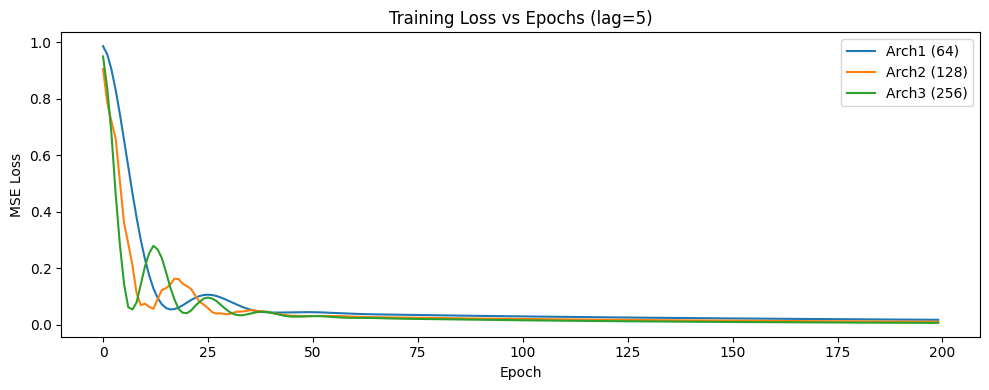

In [109]:
# Training loss plot - lag=5
plt.figure(figsize=(10, 4))
for item in all_losses_5:
    plt.plot(item['losses'], label=item['name'])
plt.title('Training Loss vs Epochs (lag=5)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

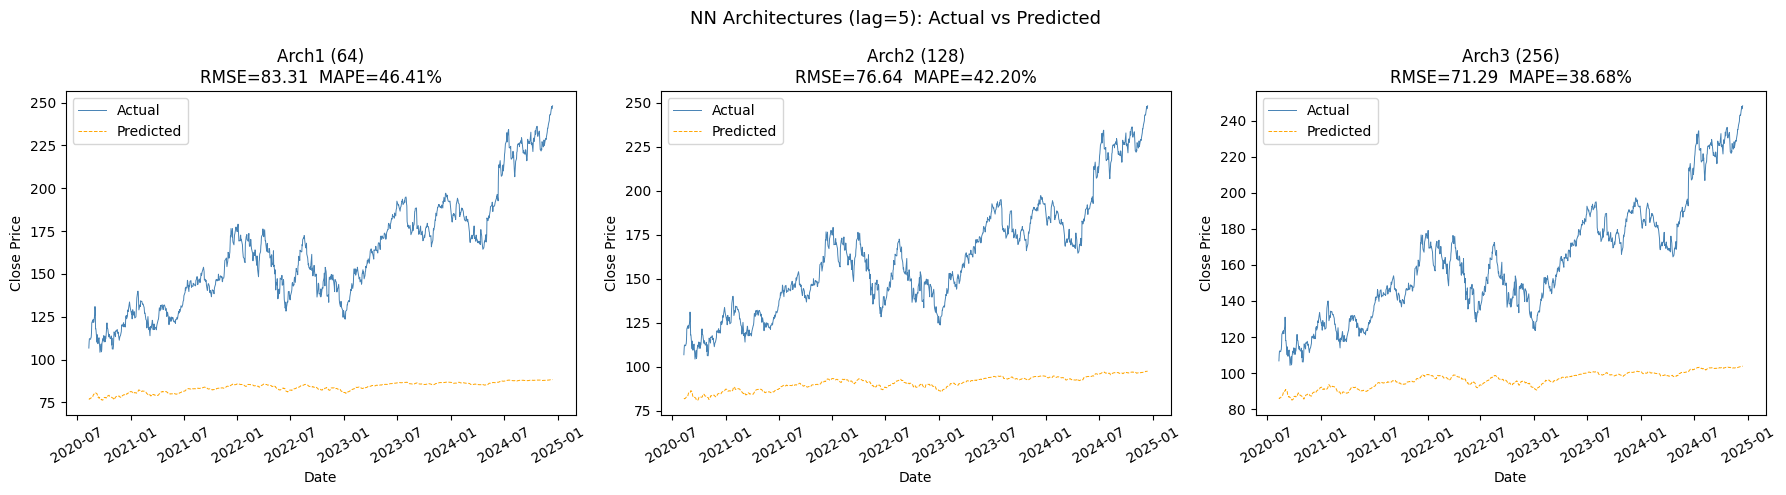

In [110]:
# Actual vs Predicted - lag=5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_index_5 = close_series.index[-(len(y_te5)):]

for idx, res in enumerate(results_5):
    axes[idx].plot(test_index_5, y_te5, label='Actual', color='steelblue', linewidth=0.7)
    axes[idx].plot(test_index_5, res['preds'], label='Predicted', color='orange', linewidth=0.7, linestyle='--')
    axes[idx].set_title(f"{res['name']}\nRMSE={res['rmse']:.2f}  MAPE={res['mape']:.2f}%")
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Close Price')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('NN Architectures (lag=5): Actual vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()

In [111]:
# Prepare lag=600 data
X_tr600, y_tr600, X_te600, y_te600, sc600 = prepare_data(series, lag=600)
print(f'lag=600  X_train: {X_tr600.shape}  X_test: {X_te600.shape}')

lag=600  X_train: torch.Size([9400, 600])  X_test: torch.Size([1094, 600])


In [ ]:
archs_600 = [
    {'name': 'Arch1 (512)',  'hidden': [512]},
    {'name': 'Arch2 (1024)', 'hidden': [1024]},
    {'name': 'Arch3 (2048)', 'hidden': [2048]},
]

results_600 = []
all_losses_600 = []

for arch in archs_600:
    print(f"\nTraining lag=600, {arch['name']}")
    torch.manual_seed(42)
    model = NNModel(input_size=600, hidden_layers=arch['hidden'])
    model, losses = train_model(model, X_tr600, y_tr600, epochs=200, lr=0.001)
    preds, r, m = evaluate_model(model, X_te600, y_te600, sc600)
    results_600.append({'name': arch['name'], 'preds': preds, 'rmse': r, 'mape': m})
    all_losses_600.append({'name': arch['name'], 'losses': losses})
    print(f"  RMSE={r:.4f}  MAPE={m:.4f}%")


Training lag=600, Arch1 (512)
  Epoch [50/200]  Loss: 0.066545
  Epoch [100/200]  Loss: 0.050672
  Epoch [150/200]  Loss: 0.040587
  Epoch [200/200]  Loss: 0.033512
  RMSE=81.4463  MAPE=45.8315%

Training lag=600, Arch2 (1024)
  Epoch [50/200]  Loss: 0.064836
  Epoch [100/200]  Loss: 0.043000
  Epoch [150/200]  Loss: 0.032160
  Epoch [200/200]  Loss: 0.025134
  RMSE=73.1687  MAPE=40.8241%

Training lag=600, Arch3 (2048)
  Epoch [50/200]  Loss: 0.059083
  Epoch [100/200]  Loss: 0.034425
  Epoch [150/200]  Loss: 0.024291


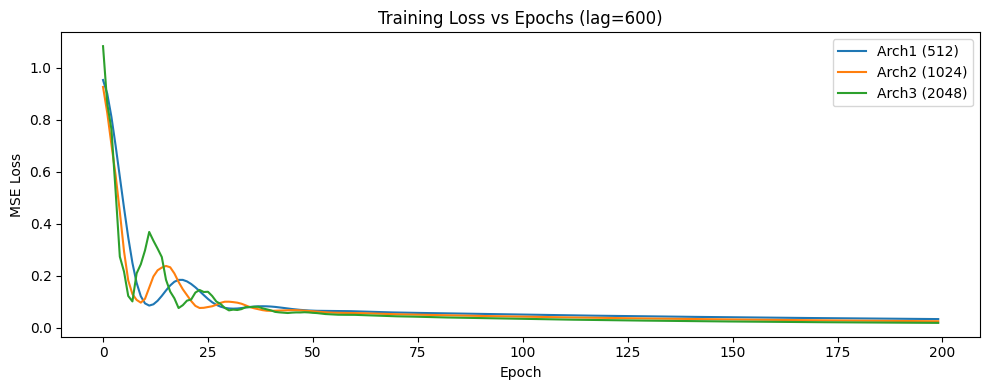

In [60]:
# Training loss plot - lag=600
plt.figure(figsize=(10, 4))
for item in all_losses_600:
    plt.plot(item['losses'], label=item['name'])
plt.title('Training Loss vs Epochs (lag=600)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

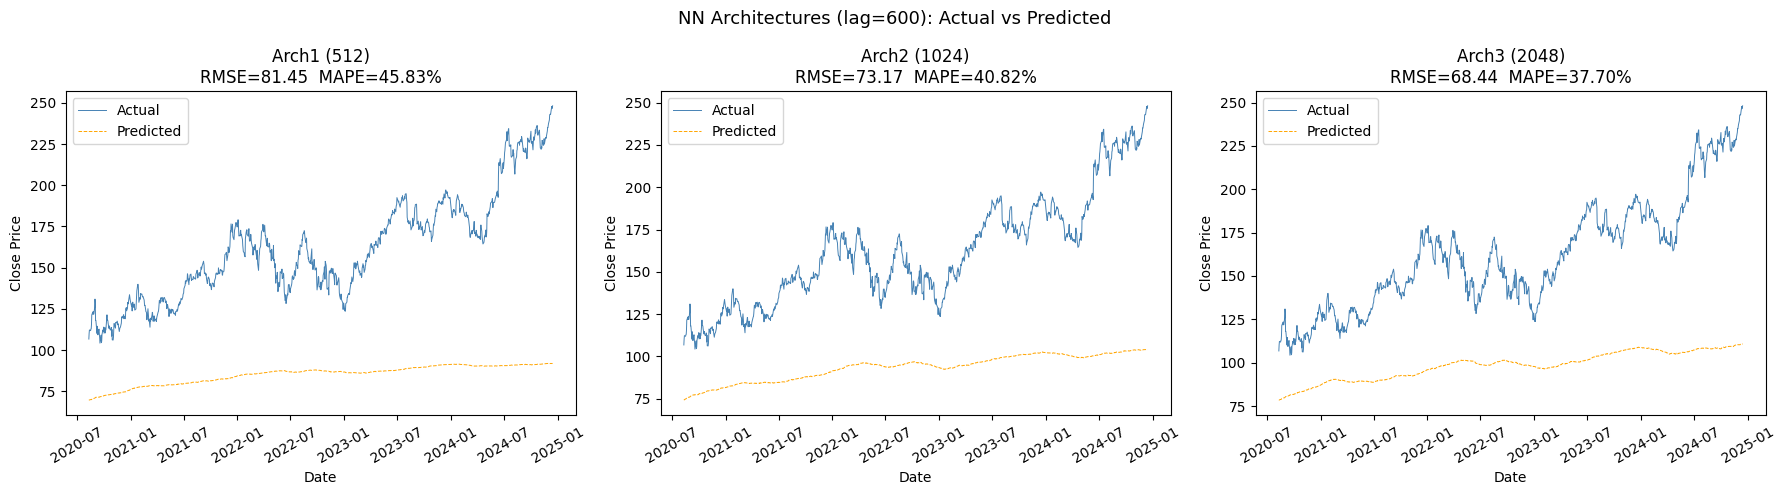

In [61]:
# Actual vs Predicted - lag=600
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_index_600 = close_series.index[-(len(y_te600)):]

for idx, res in enumerate(results_600):
    axes[idx].plot(test_index_600, y_te600, label='Actual', color='steelblue', linewidth=0.7)
    axes[idx].plot(test_index_600, res['preds'], label='Predicted', color='orange', linewidth=0.7, linestyle='--')
    axes[idx].set_title(f"{res['name']}\nRMSE={res['rmse']:.2f}  MAPE={res['mape']:.2f}%")
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Close Price')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=30)

plt.suptitle('NN Architectures (lag=600): Actual vs Predicted', fontsize=13)
plt.tight_layout()
plt.show()

In [62]:
#Comparsion
print('=' * 60)
print('PERFORMANCE COMPARISON SUMMARY')
print('=' * 60)

print('\n--- Neural Network (lag=5) ---')
for res in results_5:
    print(f"  {res['name']:18s}  RMSE={res['rmse']:.4f}  MAPE={res['mape']:.4f}%")

print('\n--- Neural Network (lag=600) ---')
for res in results_600:
    print(f"  {res['name']:18s}  RMSE={res['rmse']:.4f}  MAPE={res['mape']:.4f}%")

print('\n--- AR Models (from Q3) ---')
for lag, r, m in zip(lag_values, rmse_list, mape_list):
    if lag in [5, 600]:
        print(f'  AR(lag={lag})           RMSE={r:.4f}  MAPE={m:.4f}%')

best_nn_5   = min(results_5,   key=lambda x: x['rmse'])
best_nn_600 = min(results_600, key=lambda x: x['rmse'])

print('\n--- Best Models ---')
print(f"  Best NN (lag=5)  : {best_nn_5['name']}   RMSE={best_nn_5['rmse']:.4f}  MAPE={best_nn_5['mape']:.4f}%")
print(f"  Best NN (lag=600): {best_nn_600['name']} RMSE={best_nn_600['rmse']:.4f}  MAPE={best_nn_600['mape']:.4f}%")

print('\nComment:')
print('AR models with 1-step ahead prediction using actual history typically')
print('achieve very low RMSE/MAPE for stock prices (near-random-walk behavior).')
print('NN models may have higher error as they learn a fixed mapping from')
print('normalized inputs, losing some temporal precision.')
print('Higher lag generally helps NNs capture longer-term trends.')

PERFORMANCE COMPARISON SUMMARY

--- Neural Network (lag=5) ---
  Arch1 (64)          RMSE=83.3060  MAPE=46.4077%
  Arch2 (128)         RMSE=76.6420  MAPE=42.1957%
  Arch3 (256)         RMSE=71.2893  MAPE=38.6841%

--- Neural Network (lag=600) ---
  Arch1 (512)         RMSE=81.4463  MAPE=45.8315%
  Arch2 (1024)        RMSE=73.1687  MAPE=40.8241%
  Arch3 (2048)        RMSE=68.4376  MAPE=37.7035%

--- AR Models (from Q3) ---
  AR(lag=5)           RMSE=2.7564  MAPE=1.3277%
  AR(lag=600)           RMSE=3.9321  MAPE=1.9593%

--- Best Models ---
  Best NN (lag=5)  : Arch3 (256)   RMSE=71.2893  MAPE=38.6841%
  Best NN (lag=600): Arch3 (2048) RMSE=68.4376  MAPE=37.7035%

Comment:
AR models with 1-step ahead prediction using actual history typically
achieve very low RMSE/MAPE for stock prices (near-random-walk behavior).
NN models may have higher error as they learn a fixed mapping from
normalized inputs, losing some temporal precision.
Higher lag generally helps NNs capture longer-term trends.
